# Exploratory data analysis: employee engagement

**Project 24** | Employee engagement analyzer

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('../data/employee_engagement.csv')
print(f'Dataset: {df.shape[0]} employees, {df.shape[1]} features')
print(f'Disengagement rate: {df["is_disengaged"].mean():.1%}')
df.head()

Dataset: 8000 employees, 14 features
Disengagement rate: 3.3%


,employee_id,department,role_level,tenure_months,recognition_events_received,recognition_events_given,reward_type,monthly_recognition_frequency,avg_reward_value,peer_vs_manager_ratio,engagement_score,satisfaction_survey,absenteeism_days,is_disengaged
0,EMP-00001,Sales,Senior,40,6,6,Badge,0.50,6.47,0.75,7.0,4.6,3,0
1,EMP-00002,Customer Support,Senior,47,9,3,Points,0.75,48.41,0.48,4.4,4.2,5,0
2,EMP-00003,Operations,Junior,44,5,3,Badge,0.42,6.59,0.67,6.2,3.7,2,0
3,EMP-00004,Marketing,Manager,57,13,6,Badge,1.08,1.74,0.79,9.8,5.0,5,0
4,EMP-00005,Engineering,Mid,8,4,3,Points,0.33,43.64,0.73,6.0,3.5,6,0


In [2]:
df.describe().round(2)

,tenure_months,recognition_events_received,recognition_events_given,monthly_recognition_frequency,avg_reward_value,peer_vs_manager_ratio,engagement_score,satisfaction_survey,absenteeism_days,is_disengaged
count,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,7950.00,8000.00,8000.00
mean,32.42,6.92,3.26,0.58,53.16,0.61,7.04,4.13,4.65,0.03
std,22.19,3.78,2.64,0.31,65.98,0.21,1.55,0.66,2.57,0.18
min,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.40,0.00,0.00
25%,13.00,4.00,1.00,0.33,7.54,0.46,6.10,3.70,3.00,0.00
50%,31.00,6.00,3.00,0.50,28.10,0.63,7.10,4.20,4.00,0.00
75%,48.00,9.00,5.00,0.75,65.31,0.77,8.10,4.70,6.00,0.00
max,116.00,23.00,16.00,1.92,299.77,1.00,10.00,5.00,20.00,1.00


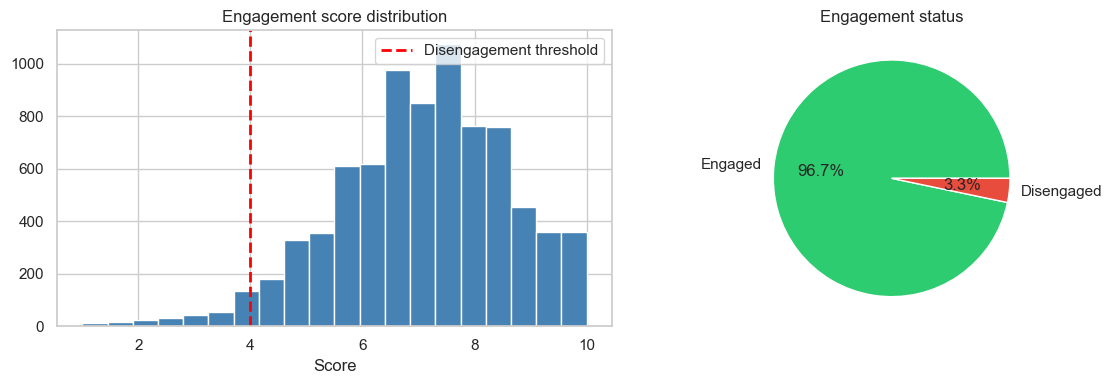

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['engagement_score'].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(4, color='red', linestyle='--', linewidth=2, label='Disengagement threshold')
axes[0].set_title('Engagement score distribution')
axes[0].set_xlabel('Score')
axes[0].legend()
df['is_disengaged'].value_counts().plot.pie(ax=axes[1], autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'], labels=['Engaged','Disengaged'])
axes[1].set_title('Engagement status')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

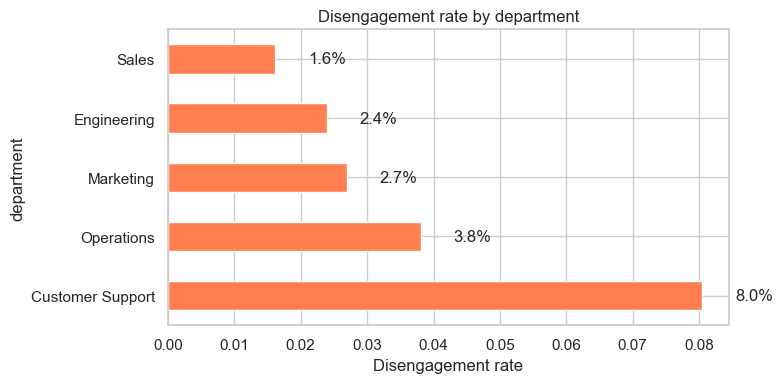

In [4]:
dept = df.groupby('department')['is_disengaged'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
dept.plot(kind='barh', color='coral', edgecolor='white', ax=ax)
ax.set_xlabel('Disengagement rate')
ax.set_title('Disengagement rate by department')
for i, v in enumerate(dept):
    ax.text(v + 0.005, i, f'{v:.1%}', va='center')
plt.tight_layout()
plt.show()

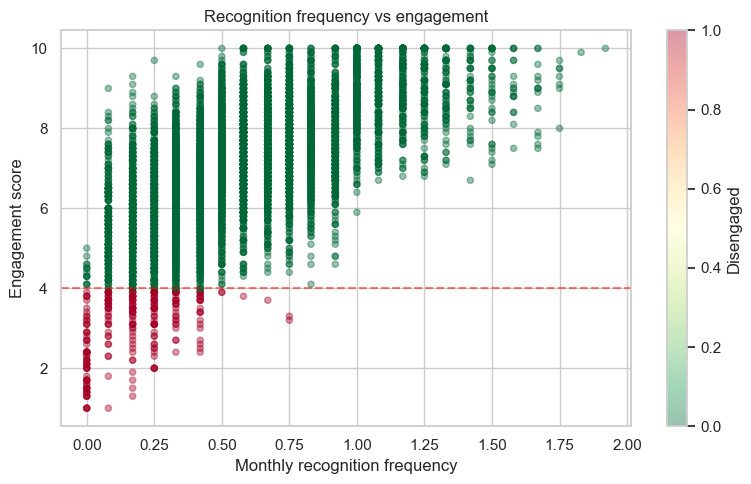

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(df['monthly_recognition_frequency'], df['engagement_score'], c=df['is_disengaged'], cmap='RdYlGn_r', alpha=0.4, s=20)
ax.set_xlabel('Monthly recognition frequency')
ax.set_ylabel('Engagement score')
ax.set_title('Recognition frequency vs engagement')
ax.axhline(4, color='red', linestyle='--', alpha=0.5)
plt.colorbar(sc, label='Disengaged')
plt.tight_layout()
plt.show()

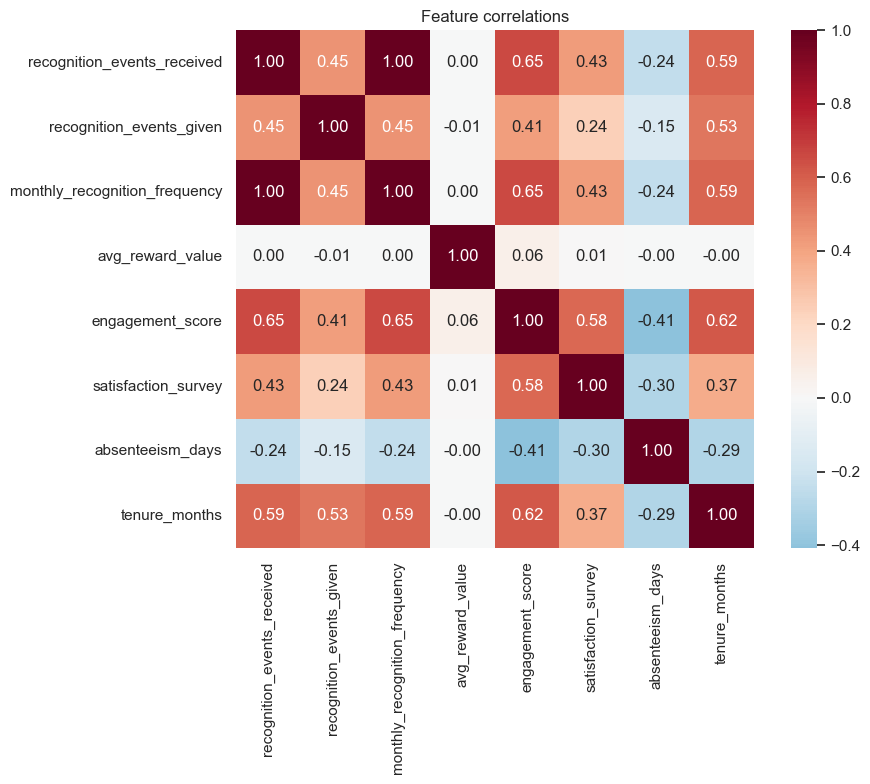

In [6]:
cols = ['recognition_events_received','recognition_events_given','monthly_recognition_frequency','avg_reward_value','engagement_score','satisfaction_survey','absenteeism_days','tenure_months']
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, square=True)
ax.set_title('Feature correlations')
plt.tight_layout()
plt.show()